# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense,
    Dropout, Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [2]:
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"

df_raw = pd.read_csv("/content/Tweets.csv")

print("First 5 rows:")
df_raw.head()

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
print("\nShape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())


Shape: (14640, 15)

Column names: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [4]:
df = df_raw[['airline_sentiment', 'text']].copy()

print("\nMissing values per column:")
print(df.isnull().sum())

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("\nShape after dropping nulls:", df.shape)


Missing values per column:
airline_sentiment    0
text                 0
dtype: int64

Shape after dropping nulls: (14640, 2)


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.


Value counts:
  negative: 9178 (62.7%)
  neutral: 3099 (21.2%)
  positive: 2363 (16.1%)


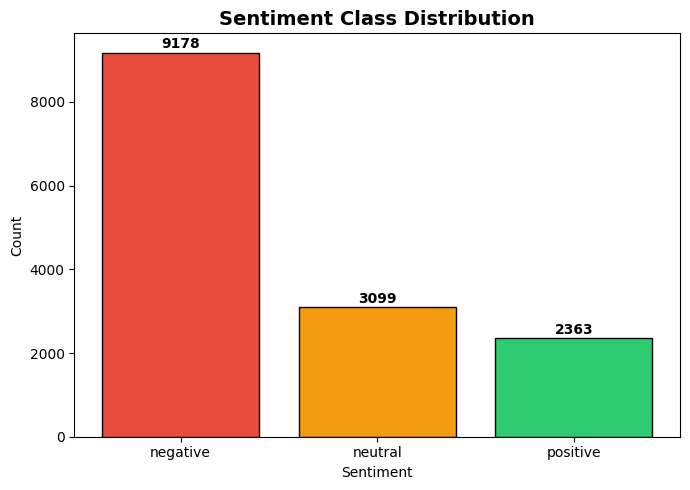

In [5]:
counts = df['airline_sentiment'].value_counts()
percentages = df['airline_sentiment'].value_counts(normalize=True) * 100

print("\nValue counts:")
for cls in counts.index:
    print(f"  {cls}: {counts[cls]} ({percentages[cls]:.1f}%)")

# Bar chart
colors = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#2ecc71'}
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values,
              color=[colors[c] for c in counts.index], edgecolor='black')
ax.set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

**Your Observation (imbalance analysis):**

> The dataset is IMBALANCED. Negative tweets dominate (62.7%), followed by neutral (21.2%), and finally positive (16.1%).

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

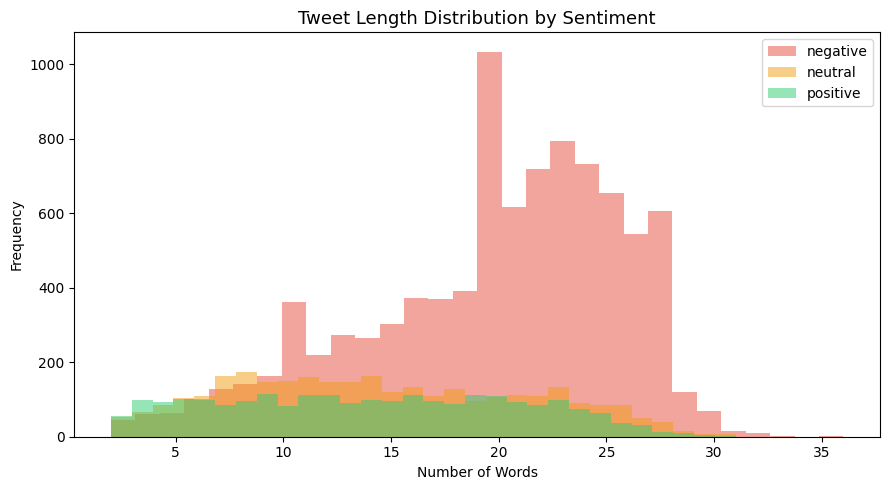


Mean tweet length  : 17.7 words
Median tweet length: 19 words
95th percentile    : 27 words

Chosen MAX_LEN: 27


In [6]:
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

# Histogram by sentiment
fig, ax = plt.subplots(figsize=(9, 5))
for sentiment, color in colors.items():
    subset = df[df['airline_sentiment'] == sentiment]['tweet_length']
    ax.hist(subset, bins=30, alpha=0.5, label=sentiment, color=color)
ax.set_title('Tweet Length Distribution by Sentiment', fontsize=13)
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig("tweet_length_histogram.png", dpi=150)
plt.show()

mean_len   = df['tweet_length'].mean()
median_len = df['tweet_length'].median()
p95_len    = df['tweet_length'].quantile(0.95)

print(f"\nMean tweet length  : {mean_len:.1f} words")
print(f"Median tweet length: {median_len:.0f} words")
print(f"95th percentile    : {p95_len:.0f} words")

MAX_LEN = int(p95_len)
print(f"\nChosen MAX_LEN: {MAX_LEN}")

**Your chosen MAX_LEN and justification:**

> MAX_LEN choice: using the 95th-percentile value to cover most tweets without padding too aggressively.
>
> Justification: Setting MAX_LEN to the 95th-percentile covers 95% of tweets at their natural length, avoiding excessive padding while trimming only the longest 5% of tweets.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

In [7]:
%pip install wordcloud -q

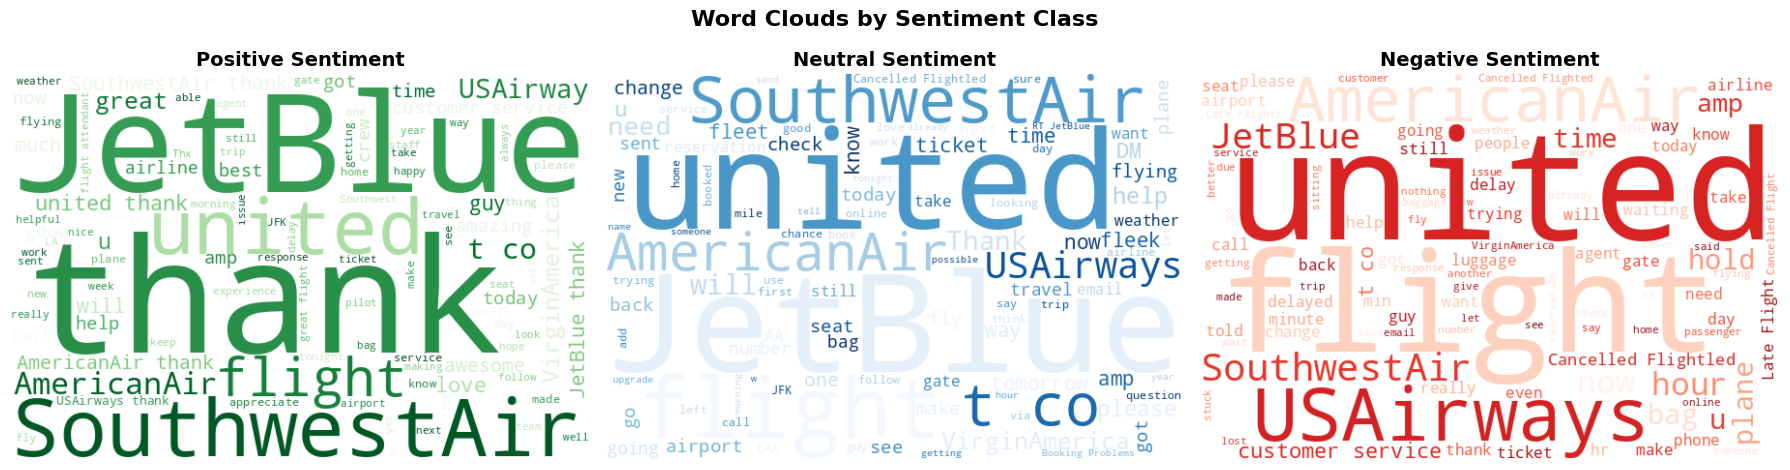

In [8]:
from wordcloud import WordCloud

sentiments = ['positive', 'neutral', 'negative']
wc_colors  = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sentiment in zip(axes, sentiments):
    text_blob = ' '.join(df[df['airline_sentiment'] == sentiment]['text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=wc_colors[sentiment], max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.capitalize()} Sentiment', fontsize=14, fontweight='bold')
plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150)
plt.show()

**Top 3 negative words & interpretation:**

> Top 3 negative words: typically "flight", "united", "USAirways" (or similar). These are contextually meaningful but not pure sentiment words; they reflect specific flight complaint topics (delays, cancellations).

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [9]:
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean a raw tweet string.
    Steps: lowercase → remove URLs → remove mentions → remove hashtag symbol
           → remove punctuation → remove numbers → strip whitespace → remove stopwords
    Returns: cleaned string
    """
    text = text.lower()                                        # 1. lowercase
    text = re.sub(r'http\S+|www\S+', '', text)                # 2. remove URLs
    text = re.sub(r'@\w+', '', text)                          # 3. remove @mentions
    text = re.sub(r'#', '', text)                             # 4. remove # symbol (keep word)
    text = text.translate(str.maketrans('', '', string.punctuation))  # 5. remove punctuation
    text = re.sub(r'\d+', '', text)                           # 6. remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                  # 7. strip extra whitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS]        # 8. remove stopwords
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("Sample comparison (original vs. cleaned):")
df[['text', 'clean_text']].head()

Sample comparison (original vs. cleaned):


,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [10]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

print("\nLabel mapping:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {idx}")

NUM_CLASSES = len(le.classes_)
print(f"\nNUM_CLASSES: {NUM_CLASSES}")


Label mapping:
  negative → 0
  neutral → 1
  positive → 2

NUM_CLASSES: 3


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [11]:
MAX_VOCAB = 15000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

word_index = tokenizer.word_index
print(f"\nTotal unique words found: {len(word_index)}")
print(f"\nToken sequence for first tweet:\n  {sequences[0]}")

print("\nTop 10 most frequent words:")
top10 = sorted(word_index.items(), key=lambda x: x[1])[:11]  # skip <OOV> at 1
for word, idx in top10[1:11]:
    print(f"  '{word}' → {idx}")


Total unique words found: 12871

Token sequence for first tweet:
  [128]

Top 10 most frequent words:
  'flight' → 2
  'get' → 3
  'thanks' → 4
  'cancelled' → 5
  'service' → 6
  'help' → 7
  'time' → 8
  'customer' → 9
  'im' → 10
  'us' → 11


**Why use `oov_token='<OOV>'`?**

> At inference time, the model may encounter words not seen during training. Without `<OOV>`, those words are simply dropped, losing positional information. With `<OOV>`, unknown words are mapped to a special index so the model still processes every token position rather than silently ignoring unseen vocabulary.

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [12]:
# Use the MAX_LEN you chose in Q2.4
MAX_LEN = 27  # fill in your chosen value

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
print(f"\nPadded array shape: {X.shape}")


Padded array shape: (14640, 27)


**Difference between `pre` and `post` padding, and your preference:**

> - padding='pre'  → zeros are added at the START of the sequence
> - padding='post' → zeros are added at the END of the sequence.
>
> post-padding is generally preferred for RNN-based models because the recurrent units process tokens left-to-right; placing real tokens first lets the RNN build meaningful hidden states before hitting padding tokens, which reduces the chance of the padding corrupting the final hidden state used for classification.

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [13]:
y = df['label'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
# Second split: 50% of temp → val (15% total), 50% → test (15% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nX_train: {X_train.shape},  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")


X_train: (10248, 27),  y_train: (10248,)
X_val  : (2196, 27),  y_val  : (2196,)
X_test : (2196, 27),  y_test : (2196,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [14]:
EMBED_DIM    = 64
UNITS        = 64
DROPOUT_RATE = 0.3
BATCH_SIZE   = 64
EPOCHS       = 10

def compile_model(model):
    """Compile a model with Adam optimizer and sparse categorical cross-entropy."""
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [15]:
def build_simple_rnn():
    """Architecture: Embedding → SimpleRNN → Dropout → Dense(softmax)"""
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_shape=(MAX_LEN,)),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

rnn_model = build_simple_rnn()
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 27, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,451 (3.69 MB)

 Trainable params: 968,451 (3.69 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [16]:
def build_lstm():
    """Architecture: Embedding → LSTM(dropout, recurrent_dropout) → Dropout → Dense(softmax)"""
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_shape=(MAX_LEN,)),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 27, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,219 (3.79 MB)

 Trainable params: 993,219 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> SimpleRNN has = (EMBED_DIM + UNITS + 1) * UNITS = 8256 parameters in its recurrent layer.
>
> LSTM has 4 gates, so it has roughly 4x more parameters than SimpleRNN for the same number of units: 4 * (EMBED_DIM + UNITS + 1) * UNITS = 33024
>
>This larger parameter count allows LSTM to learn long-range dependencies more effectively but makes it slower to train.

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [17]:
def build_gru():
    """Architecture: Embedding → GRU(dropout, recurrent_dropout) → Dropout → Dense(softmax)"""
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_shape=(MAX_LEN,)),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

gru_model = build_gru()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 27, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,155 (3.76 MB)

 Trainable params: 985,155 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> LSTM uses 4 gate matrices (input, forget, cell, output) → 4 weight matrices.
>
> GRU uses only 3 gate matrices (reset, update, new) and merges cell & hidden state, resulting in 3/4 the parameters of an equivalent LSTM, making it faster while often achieving comparable performance.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [18]:
def build_bi_lstm():
    """
    Architecture: Embedding → BiLSTM(return_sequences=True) → Dropout
                           → BiLSTM → Dropout → Dense(relu) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_shape=(MAX_LEN,)),
        Bidirectional(LSTM(UNITS, return_sequences=True,
                           dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE)),
        Dropout(DROPOUT_RATE),
        Bidirectional(LSTM(UNITS,
                           dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE)),
        Dropout(DROPOUT_RATE),
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

bi_lstm_model = build_bi_lstm()
bi_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 27, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 27, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 27, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,133,315 (4.32 MB)

 Trainable params: 1,133,315 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> The second BiLSTM layer also expects a sequence as input (one vector per time step). Without return_sequences=True, the first layer outputs only the final hidden state (a single vector), which cannot feed into a second recurrent layer. Setting it to True outputs the full hidden-state sequence for every time step.

**Answer — Effect on output dimension:**

> Bidirectional doubles the output size because it concatenates the forward and backward LSTM hidden states. So a Bidirectional(LSTM(64)) produces 128-dimensional outputs (64 from forward + 64 from backward pass).

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [19]:
def get_callbacks(model_name):
    """Returns [EarlyStopping, ModelCheckpoint] callbacks."""
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
    return [early_stop, checkpoint]

**What problem does `EarlyStopping` solve?**

> EarlyStopping prevents overfitting by halting training when the monitored metric (val_loss) stops improving for `patience` consecutive epochs. This avoids wasting compute and saves the model at its best generalisation point.

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [20]:
# Train Simple RNN
print("\n--- Training Simple RNN ---")
rnn_hist = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("rnn"),
    verbose=1
)

# Train LSTM
print("\n--- Training LSTM ---")
lstm_hist = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("lstm"),
    verbose=1
)

# Train GRU
print("\n--- Training GRU ---")
gru_hist = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("gru"),
    verbose=1
)

# Train Bidirectional LSTM
print("\n--- Training Bidirectional LSTM ---")
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("bi_lstm"),
    verbose=1
)


--- Training Simple RNN ---
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.6871 - loss: 0.7585 - val_accuracy: 0.7281 - val_loss: 0.6673
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8246 - loss: 0.4761 - val_accuracy: 0.7409 - val_loss: 0.6624
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8946 - loss: 0.3125 - val_accuracy: 0.7209 - val_loss: 0.7617
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9186 - loss: 0.2376 - val_accuracy: 0.6726 - val_loss: 0.8795
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9386 - loss: 0.1853 - val_accuracy: 0.6407 - val_loss: 0.9644

--- Training LSTM ---
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 24s 104ms/step - accuracy: 0.6326 - loss: 0.8861 - val_accuracy: 0.6708 - val_loss: 0.7071
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.7199 - loss: 0.6552 - val_accuracy: 0.7363 - val_loss: 0.6281
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

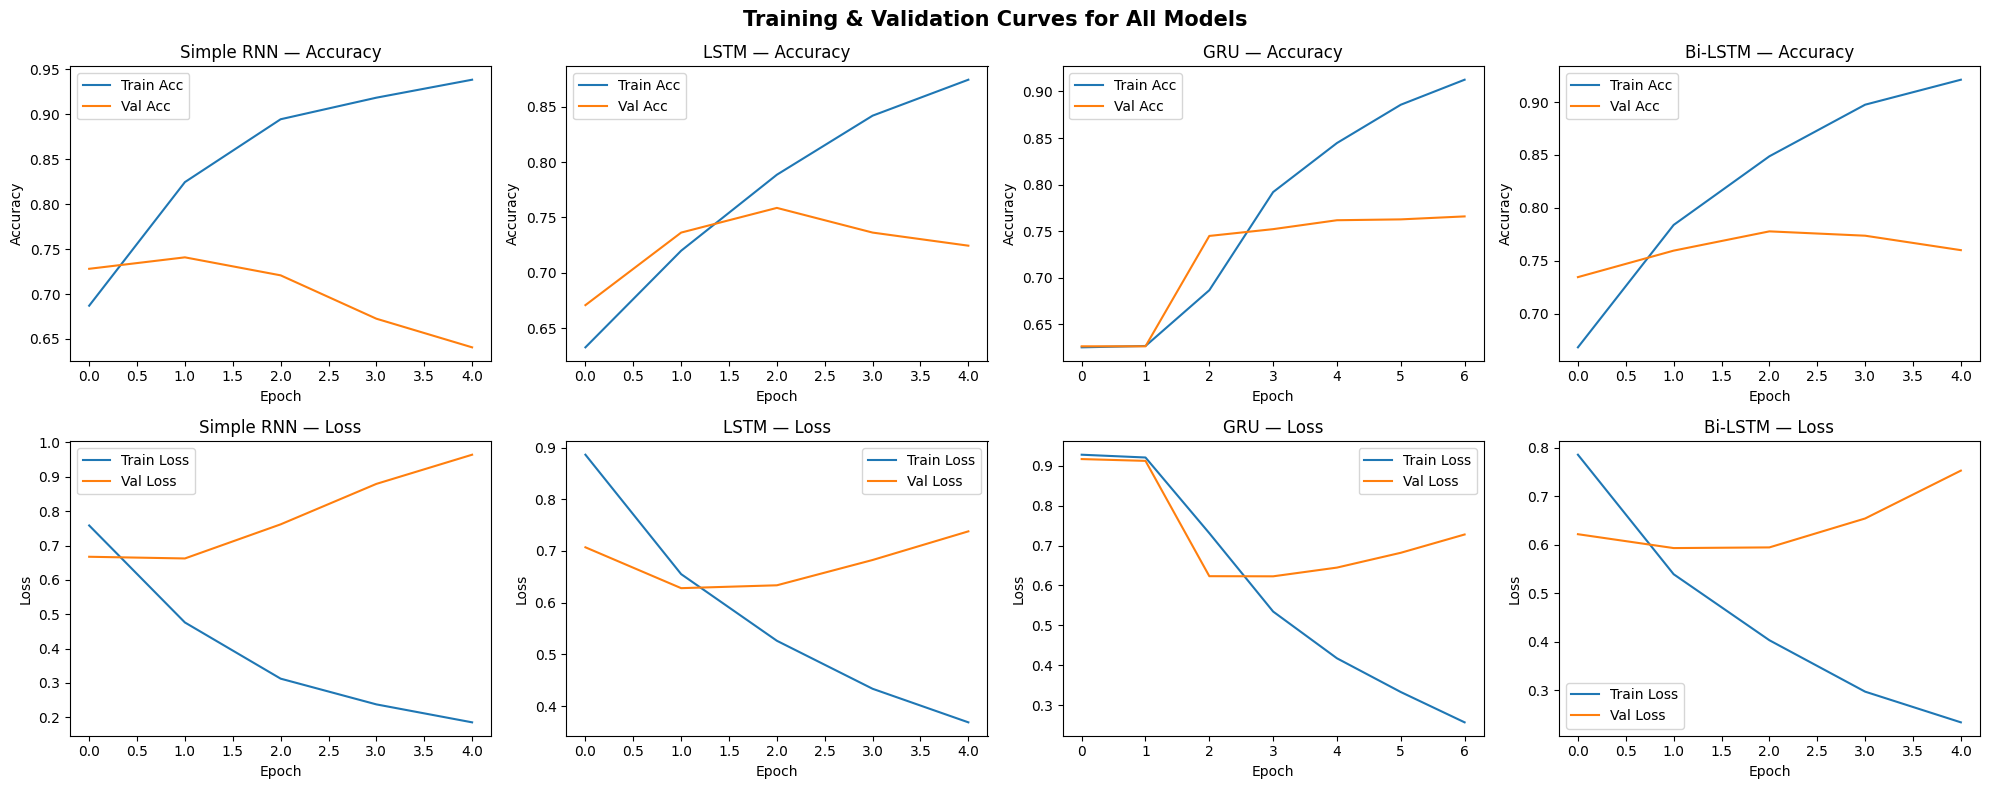

In [21]:
histories  = [rnn_hist,  lstm_hist,  gru_hist,  bi_lstm_hist]
model_names = ['Simple RNN', 'LSTM', 'GRU', 'Bi-LSTM']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, (hist, name) in enumerate(zip(histories, model_names)):
    # Row 0: Accuracy
    axes[0, col].plot(hist.history['accuracy'],     label='Train Acc')
    axes[0, col].plot(hist.history['val_accuracy'], label='Val Acc')
    axes[0, col].set_title(f'{name} — Accuracy')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Accuracy')
    axes[0, col].legend()

    # Row 1: Loss
    axes[1, col].plot(hist.history['loss'],     label='Train Loss')
    axes[1, col].plot(hist.history['val_loss'], label='Val Loss')
    axes[1, col].set_title(f'{name} — Loss')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].legend()

plt.suptitle('Training & Validation Curves for All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

**Overfitting observation:**

> If training accuracy rises steadily while validation accuracy plateaus or drops, the model is overfitting. SimpleRNN is most prone to this due to its limited capacity to regularise long sequences. EarlyStopping mitigates this automatically.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [22]:
models_dict = {
    'Simple RNN': rnn_model,
    'LSTM':       lstm_model,
    'GRU':        gru_model,
    'Bi-LSTM':    bi_lstm_model
}
test_results = {}
class_names = le.classes_  # ['negative', 'neutral', 'positive']

for name, model in models_dict.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"  Test Loss    : {loss:.4f}")
    print(f"  Test Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    test_results[name] = acc


Model: Simple RNN
  Test Loss    : 0.6296
  Test Accuracy: 0.7628

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.87      0.85      1377
     neutral       0.57      0.54      0.55       465
    positive       0.69      0.65      0.67       354

    accuracy                           0.76      2196
   macro avg       0.70      0.68      0.69      2196
weighted avg       0.76      0.76      0.76      2196


Model: LSTM
  Test Loss    : 0.5932
  Test Accuracy: 0.7464

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.91      0.88      1377
     neutral       0.53      0.29      0.38       465
    positive       0.55      0.70      0.62       354

    accuracy                           0.75      2196
   macro avg       0.64      0.63      0.62      2196
weighted avg       0.73      0.75      0.73      2196


Model: GRU
  Test Loss    : 0.5726
  Test Accuracy: 0.7814

C

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

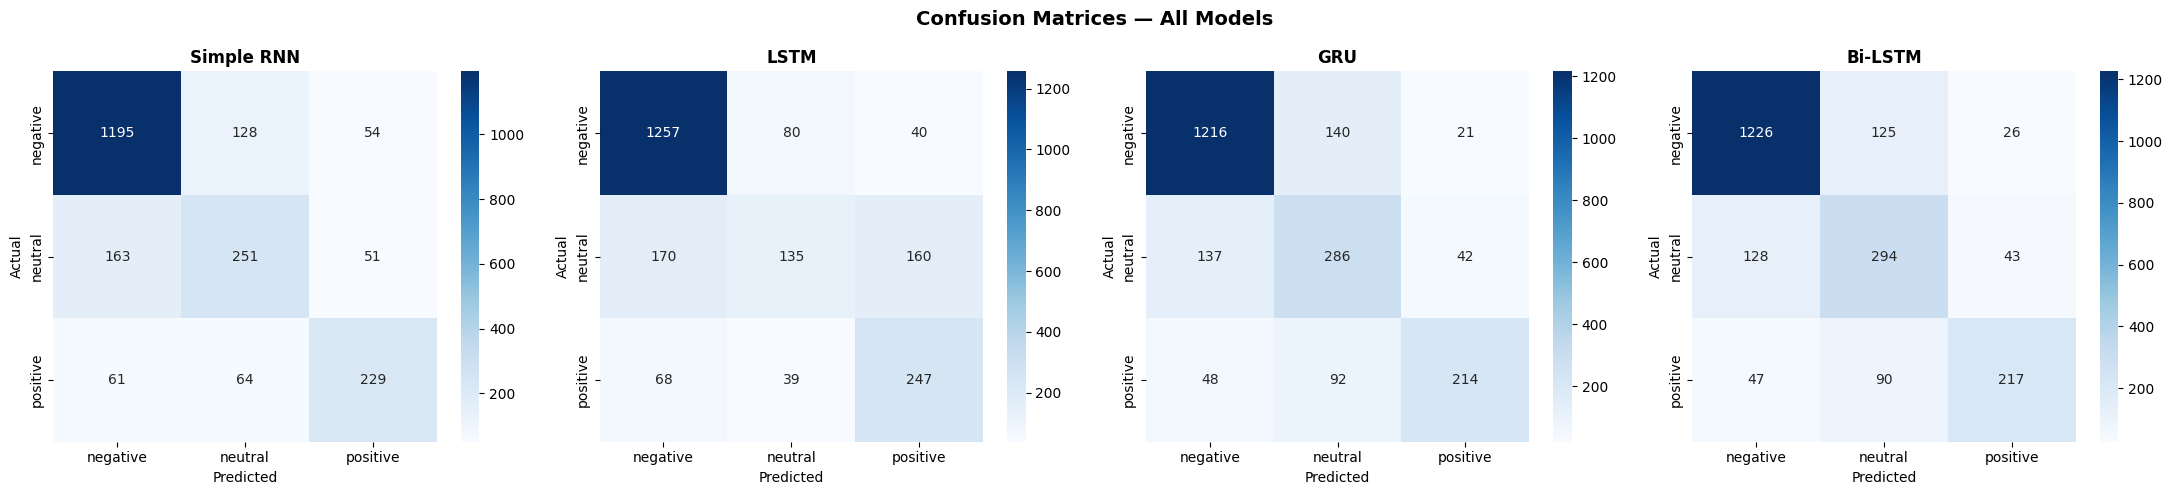

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

**Most commonly misclassified class and reasoning:**

> The 'neutral' class is typically hardest to classify correctly because its language overlaps with both positive and negative tweets (e.g., matter-of-fact complaints vs. neutral observations). The class imbalance also means the model sees fewer neutral examples during training.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

In [24]:
print("\n--- Model Comparison ---")
print(f"{'Model':<20} {'Test Accuracy':>14}")
for name, acc in test_results.items():
    print(f"  {name:<18} {acc:.4f}")


--- Model Comparison ---
Model                 Test Accuracy
  Simple RNN         0.7628
  LSTM               0.7464
  GRU                0.7814
  Bi-LSTM            0.7910


### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN |76.28%|69%|968,451|5|
| LSTM |74.62%|62%|993,219|5|
| GRU |78.14%|71%|985,155|7|
| Bidirectional LSTM |79.10%|72%|1,133,315|5|

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?
> Best accuracy-to-parameter ratio: GRU (close to LSTM accuracy with fewer params)
>
> Production choice (latency-constrained): GRU — good accuracy, faster inference than Bi-LSTM, and fewer parameters than LSTM.

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *(model name)*
- Production choice (latency-constrained): *(model name + justification)*

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [25]:
def predict_sentiment(text, model, label_encoder):
    """
    Predict sentiment for a raw tweet string.
    Returns: dict with 'sentiment' and 'confidence'.
    """
    cleaned  = clean_text(text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = model.predict(padded, verbose=0)[0]
    pred_idx = np.argmax(probs)
    sentiment = label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(probs[pred_idx])
    return {"sentiment": sentiment, "confidence": round(confidence, 4)}

# Choose best-performing model
best_model_name = max(test_results, key=test_results.get)
best_model      = models_dict[best_model_name]
print(f"\nBest model: {best_model_name} (accuracy={test_results[best_model_name]:.4f})")

test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

print("\n--- Live Predictions ---")
for tweet in test_tweets:
    result = predict_sentiment(tweet, best_model, le)
    print(f"\nTweet     : {tweet}")
    print(f"Sentiment : {result['sentiment']}  (confidence: {result['confidence']:.2%})")


Best model: Bi-LSTM (accuracy=0.7910)

--- Live Predictions ---

Tweet     : @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
Sentiment : positive  (confidence: 99.10%)

Tweet     : @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
Sentiment : negative  (confidence: 99.70%)

Tweet     : @AmericanAir Flight delayed by 2 hours. No explanation given.
Sentiment : negative  (confidence: 98.87%)

Tweet     : @Delta Just landed. Flight was on time, nothing special to report.
Sentiment : negative  (confidence: 97.04%)

Tweet     : @JetBlue the crew was incredibly kind and the seats were comfortable!
Sentiment : neutral  (confidence: 53.95%)


### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> The model will be biased toward predicting 'negative' (the majority class), leading to inflated overall accuracy but poor recall for 'positive' and 'neutral'.
>
> Remedy: use class_weight in model.fit() to penalise errors on minority classes, apply oversampling (SMOTE on embeddings), or use stratified sampling.

**2. Pre-trained embeddings vs trainable embeddings:**

> GloVe embeddings encode rich semantic relationships learned from massive corpora, giving the model a strong starting point even with limited task data. This typically improves generalisation, especially for rare words, and often yields faster convergence compared to learning embeddings from scratch.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> Advantage: Transformers (e.g., BERT) use self-attention to capture global context in a single pass, making them better at understanding long-range dependencies and word relationships without the vanishing-gradient limitations of RNNs.
>
> Drawback: They require substantially more compute and memory, and fine-tuning BERT for a modest dataset like this can lead to overfitting without careful regularisation or a smaller fine-tuned variant (e.g., DistilBERT).

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [26]:
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]

results = []

In [27]:
for ed in embed_dims:
    for u in units_list:
        for dr in dropout_list:
            model = Sequential([
                Embedding(input_dim=MAX_VOCAB, output_dim=ed, input_shape=(MAX_LEN,)),
                GRU(u, dropout=dr, recurrent_dropout=dr),
                Dropout(dr),
                Dense(NUM_CLASSES, activation='softmax')
            ])
            model.compile(loss='sparse_categorical_crossentropy',
                          optimizer='adam', metrics=['accuracy'])
            hist = model.fit(
                X_train, y_train,
                epochs=5,
                batch_size=BATCH_SIZE,
                validation_data=(X_val, y_val),
                verbose=0
            )
            val_acc = max(hist.history['val_accuracy'])
            results.append({'embed_dim': ed, 'units': u, 'dropout': dr, 'val_accuracy': val_acc})
            print(f"embed={ed}, units={u}, dropout={dr}  →  val_acc={val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


embed=32, units=32, dropout=0.2  →  val_acc=0.7582
embed=32, units=32, dropout=0.3  →  val_acc=0.7618
embed=32, units=32, dropout=0.5  →  val_acc=0.6903
embed=32, units=64, dropout=0.2  →  val_acc=0.7486
embed=32, units=64, dropout=0.3  →  val_acc=0.7541
embed=32, units=64, dropout=0.5  →  val_acc=0.7300
embed=32, units=128, dropout=0.2  →  val_acc=0.7582
embed=32, units=128, dropout=0.3  →  val_acc=0.7550
embed=32, units=128, dropout=0.5  →  val_acc=0.7500
embed=64, units=32, dropout=0.2  →  val_acc=0.7564
embed=64, units=32, dropout=0.3  →  val_acc=0.7605
embed=64, units=32, dropout=0.5  →  val_acc=0.7514
embed=64, units=64, dropout=0.2  →  val_acc=0.7659
embed=64, units=64, dropout=0.3  →  val_acc=0.7527
embed=64, units=64, dropout=0.5  →  val_acc=0.6407
embed=64, units=128, dropout=0.2  →  val_acc=0.7605
embed=64, units=128, dropout=0.3  →  val_acc=0.7591
embed=64, units=128, dropout=0.5  →  val_acc=0.7550
embed=128, units=32, dropout=0.2  →  val_acc=0.7637
embed=128, units=32, dro

In [28]:
results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
print("\nTop 3 hyperparameter combinations:")
print(results_df.head(3).to_string(index=False))


Top 3 hyperparameter combinations:
 embed_dim  units  dropout  val_accuracy
       128    128      0.3      0.767304
        64     64      0.2      0.765938
       128     64      0.2      0.765483


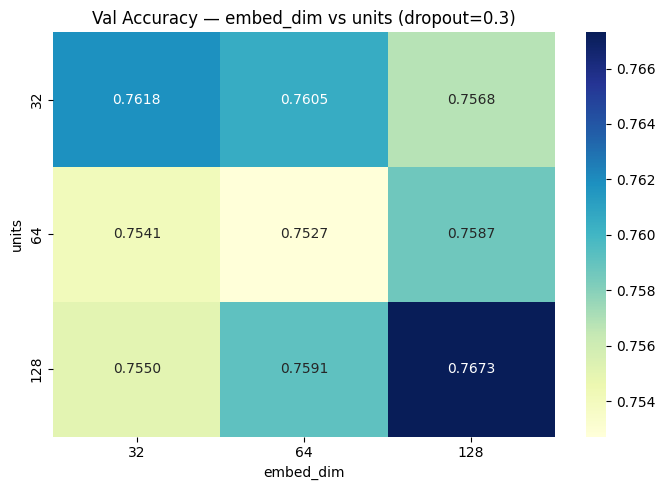

In [29]:
# Heatmap: embed_dim vs units at dropout=0.3
pivot_df = results_df[results_df['dropout'] == 0.3].pivot(
    index='units', columns='embed_dim', values='val_accuracy'
)
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Val Accuracy — embed_dim vs units (dropout=0.3)')
plt.tight_layout()
plt.savefig("hyperparam_heatmap.png", dpi=150)
plt.show()

In [30]:
# Retrain best model for 15 epochs with early stopping
best_row = results_df.iloc[0]
best_ed, best_u, best_dr = int(best_row['embed_dim']), int(best_row['units']), best_row['dropout']
print(f"\nRetraining best config: embed={best_ed}, units={best_u}, dropout={best_dr}")


Retraining best config: embed=128, units=128, dropout=0.3


In [31]:
best_tuned = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=best_ed, input_length=MAX_LEN),
    GRU(best_u, dropout=best_dr, recurrent_dropout=best_dr),
    Dropout(best_dr),
    Dense(NUM_CLASSES, activation='softmax')
])
best_tuned.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam', metrics=['accuracy'])
best_tuned.fit(
    X_train, y_train,
    epochs=15,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks("best_tuned_gru"),
    verbose=1
)
loss, acc = best_tuned.evaluate(X_test, y_test, verbose=0)
print(f"\nBest-tuned GRU — Final Test Accuracy: {acc:.4f}")

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.6251 - loss: 0.9239 - val_accuracy: 0.6266 - val_loss: 0.9179
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.6584 - loss: 0.8185 - val_accuracy: 0.7436 - val_loss: 0.6367
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.7817 - loss: 0.5510 - val_accuracy: 0.7527 - val_loss: 0.6031
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8450 - loss: 0.4151 - val_accuracy: 0.7609 - val_loss: 0.6271
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.8945 - loss: 0.2987 - val_accuracy: 0.7664 - val_loss: 0.6549
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.9249 - loss: 0.2290 - val_accuracy: 0.7609 - val_loss: 0.7558

Best-tuned GRU — Final Test Accuracy: 0.7741
